# American Option Pricing with gSS and fTT



## Libraries:

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")  # silences the tf.compat.v1 deprecations

import time
import keras
import scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats
from functools import reduce
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer 
from sklearn.preprocessing import StandardScaler

# Libraries Created by the Authors
# Method (1)
from nnu import points_generator as pgen
from nnu import laplace_kernel, fit_function_factory
from nnu import gss_layer, gss_model_factory, gss_report_config
# Method (2)
from nnu import gss_kernels as ssk
from nnu import ftt_regression as ftt
from nnu import points_generator as pgen
from nnu import gss_report_config as ssrg

# Global
np.set_printoptions(precision = 5, suppress = True)
keras.config.set_floatx("float64")

## Reading and Viewing Data

### Reading the Data

In [2]:
data = pd.read_csv("data_ML.csv")

### Displaying Some Info About the Dataset

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100455 entries, 0 to 100454
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asset_price  100455 non-null  float64
 1   maturity     100455 non-null  float64
 2   rate         100455 non-null  float64
 3   div          100455 non-null  float64
 4   ivol         100455 non-null  float64
 5   european_op  100455 non-null  float64
 6   american_op  100455 non-null  float64
dtypes: float64(7)
memory usage: 5.4 MB


We can observe that the dataset includes `100455 observations` and `7 parameters`. In our case, we are going to use the first 6 parameters to predict the value of the 7th parameter (`american_op`).

### View First 5 and Last 5 Data Points

#### Top 5 data points



In [4]:
data.head(5)

,asset_price,maturity,rate,div,ivol,european_op,american_op
0,113.935171,0.285741,0.008467,0.023575,0.538127,6.612110,6.612107
1,98.305405,0.813916,0.019547,0.018027,0.048863,2.601042,2.626842
2,109.189731,0.713558,0.022951,0.015280,0.303538,6.397872,6.430745
3,83.402084,2.879962,0.042272,0.058719,0.163288,20.609465,20.903553
4,127.549831,0.907992,0.026664,0.017533,0.562713,12.093558,12.156191


#### Last 5 data points

In [5]:
data.tail(5)

,asset_price,maturity,rate,div,ivol,european_op,american_op
100450,76.042759,0.102861,0.025629,0.034502,0.171373,23.963362,23.964726
100451,102.305683,0.832775,0.028396,0.005028,0.315285,9.426943,9.583641
100452,75.284271,2.685636,0.053380,0.023887,0.298182,24.476452,27.715600
100453,122.245305,4.843896,0.003533,0.034317,0.287358,22.513830,22.513776
100454,104.543032,0.648455,0.049105,0.069530,0.415862,11.606876,11.625611


## Splitting the Dataset into a Training and Testing sets

In [6]:
train = data.sample(frac = 0.70, random_state = 1)
test = data.drop(train.index)

In [7]:
# Learn the scaling from the TRAINING data only

scaler = StandardScaler()
scaler.fit(train.to_numpy()[:, :-1])

StandardScaler()

## Fitting the Models

References:
1.   [Authors' Github Repository](https://github.com/piterbarg/altnnpub)
2.   [One-dimensional generalized Stochastic Sampling (gSS)](https://github.com/piterbarg/altnnpub/blob/main/gss_example_model_factory_01.ipynb)

### Fitting the One-dimensional ("onedim") generalized Stochastic Sampling (gSS) Algorithm

#### **1.** Setting the Number of Dimensions (Features)

In [8]:
ndim = 6 # Number of Dimensions / Features (asset_price, maturity, rate, div, ivol, european_op)

#### **2.** Preparing the Learning Set

We already have the learning set stored as `train`. However, currently we will prepare the learning set to satisfy the functions we are going to use. For instance, we will divide the `train` set into `inputX` and `inputY`.

In [9]:
inputX = scaler.transform(train.to_numpy()[:, :-1])
inputY = train.to_numpy()[:,-1]

nsamples = train.shape[0] # Number of Samples // Number of Rows (of the train set)

#### **3.** Generating Nodes for the Model



In [10]:
# Setting the Nodes Type to Random
# Can be Set to Regular by -> nodes_type = "regular"
nodes_type = "random"

# Setting the Seed that will be Used in Generating the Nodes
nodes_seed = 1

# Setting the Number of Nodes
nnodes = 1000

# Setting the Simulation Range
sim_range = 4

# Setting the Stretch Factor
nsr_stretch = 1.2

# Computing the `Nodes` Simulation Range
nodes_sim_range = sim_range * nsr_stretch

# Generating the Nodes
nodes = pgen.generate_points(nodes_sim_range, nnodes, ndim, nodes_type,
                             seed = nodes_seed, plot = 0)[0]

# Calculating the Global Scale
# Likely to be the Average Distance Between Nodes
global_scale = pgen.average_distance(nodes)

#### **4.** Setting Up the "onedim" gSS Model

In [11]:
# Defining tensor flow (tf) and numpy (np) Datatypes
# We defined them as float64 instead of float32; float32 is 
# insufficient, because the normal-equations solve is ill-conditioned
tf_dtype = tf.float64
np_dtype = np.float64

# Initializing a Dictionary that Includes the Model Specifications
# Those specs will be re-used few times
model_specs = dict(model_type=gss_report_config.ModelType.SSL,
                   use_outer_regression=True,
                   optimize_knots=False,
                   optimize_scales=True,
                   scales_dim=gss_layer.ScalesDim.OnlyOne,
                   apply_final_aggr =False,
                   kernel='invquad', # invquad : inverse quadratic kernel
                   )

# Setting a Seed for Keras
seed_for_keras = 1

# Generating a Model
model = gss_model_factory.generate_model(ndim=ndim,
                                         global_scale=global_scale,
                                         nodes=nodes,
                                         inputX=inputX,
                                         inputY=inputY,
                                         scales=None,
                                         seed_for_keras=seed_for_keras,
                                         **model_specs,                   # Unpack Dictionary
                                         l2_regularizer=1e-6,             # Paper (section 4.6): ""typically set to 1e-6" for onedim"; default (1e-4) over-damps
                                         )

# Due to how the model is constructed, the fit( ) function uses some fake xs
# The real inputX and inputY are 'side-loaded' into the model through 'xpts' and 'ypts' layers

# Setting a FAKE Dimension
fake_dim = 1 # onedim

# Setting the Number of Output Samples // Setting the Output Size
output_size = nsamples

# Defining the FAKE Set of Inputs
x_to_use = np.zeros((output_size, fake_dim), dtype = np_dtype) # One Column

# Printing a Summary of the Entire Model ("fit_model")
model.summary()

# Printing a Summary of the 'predict_y_model' Layer within the Model
model.get_layer('predict_y_model').summary()

Model: "fit_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ypts (Lambda)       │ (70318, 1)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predict_y_model     │ (70318, 1)        │      6,001 │ input[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resid_xy (Subtract) │ (70318, 1)        │          0 │ ypts[0][0],       │
│                     │                   │            │ predict_y_model[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,001 (46.88 KB)

 Trainable params: 1 (8.00 B)

 Non-trainable params: 6,000 (46.88 KB)

Model: "predict_y_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xpts (Lambda)       │ (70318, 6)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prodkernel          │ (70318, 1000, 6)  │      6,001 │ xpts[0][0]        │
│ (ProdKernelLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product (Lambda)    │ (70318, 1000)     │          0 │ prodkernel[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regr_xy_model       │ (1000, 1)         │      6,001 │ input[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predict_y (Lambda)  │ (70318, 1)        │          0 │ product[0][0],    │
│                     │                   │            │ regr_xy_model[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,001 (46.88 KB)

 Trainable params: 1 (8.00 B)

 Non-trainable params: 6,000 (46.88 KB)

#### **5.** Calculating the Average Gradients

"We create a 'test' model to calculate gradients. The test model will have its outer weights (linear coefficients) calculated by regression so this is the "base" approximation from the paper."

In [12]:
# Generating a Gradient Model (for testing purposes)
grad_model = gss_model_factory.generate_model_for_testing_2(model,
                                                            ndim=ndim,
                                                            global_scale=global_scale,
                                                            nodes=nodes,
                                                            **model_specs, # Unpack Dictionary
                                                            average_slopes=None,
                                                            l2_regularizer=1e-6,
                                                            tf_dtype=tf_dtype,
                                                            nsr_stretch=nsr_stretch,
                                                            generate_more_nodes=False,
                                                            sim_range=sim_range)

grad_batch = max(64, 800000 // nnodes) 

sum_sq = np.zeros(ndim)
# Calculating the Gradients Using Tensorflow (tf)
for i in range(0, inputX.shape[0], grad_batch):
  x_chunk = tf.convert_to_tensor(inputX[i:(i + grad_batch)], dtype = tf_dtype)  # Convert Input Samples to Tensorflow Tensor
  with tf.GradientTape() as t:
    t.watch(x_chunk)
    output = grad_model(x_chunk)
  gradients = t.gradient(output, x_chunk).numpy()  # Calculating the Gradient of the Output Using Tensorflow
  sum_sq += (gradients ** 2).sum(axis=0)  # Summing the Squares of the Gradients
  del x_chunk, output, gradients

# Calculating the Average Directional Risk Magnitudes
average_slopes = np.sqrt(sum_sq)  # Calculating the Euclidean Norm ( == np.linalg.norm(gradients, axis = 0))
average_slopes /= np.amax(average_slopes) # Normalizing the Magnitudes
print("Normalized Directional Risk Magnitudes: ", average_slopes)

Normalized Directional Risk Magnitudes:  [0.50939 0.2186  0.10178 0.06256 0.26712 1.     ]


#### **6.** Re-initialize the Model with the Calculated Average Slopes

In [13]:
# Redefine the model, since we now know average_slopes
model = gss_model_factory.generate_model(
    ndim=ndim, 
    global_scale=global_scale,
    nodes=nodes,
    inputX=inputX,
    inputY=inputY,
    scales=None, 
    seed_for_keras=seed_for_keras,
    **model_specs,
    average_slopes=average_slopes,
    sim_range=sim_range
)

#### **7.** Fit the gSS Model

"We run a one-dim optimizer for the global scale of the kernels with linear regression for outer (linear) coefficients on each step."

In [14]:
# Get access to the inner weight corresponding to the common scale (standard scalar) that drives 
# all scales so we can set it directly and optimize in a 1d optimizer
predict_model = model.get_layer('predict_y_model')
prod_kernel = predict_model.get_layer('prodkernel')
orig_weights = prod_kernel.get_weights() # get the original weights of the prodkernel layer

def obj_f_1d(w): 
    '''
    1D objective function for scipy.optimize.minimize_scalar
    '''
    # set the right weight to w, and reuse the others (nodes are not trainable here)
    prod_kernel.set_weights([np.array([[w]]), orig_weights[1]])

    fit = predict_model.predict(x_to_use, batch_size=nsamples)
    rel_l2 = np.linalg.norm(fit[:, 0] - inputY) / np.linalg.norm(inputY)  # ‖f−y‖₂ / ‖y‖₂
    return rel_l2

res = scipy.optimize.minimize_scalar(
    obj_f_1d, 
    bounds=(0.25, 4.00), 
    method="bounded",        # never evaluates obj_f_1d outside the bounds
    options={"xatol": 1e-2}  # stop once the bracket on w narrows below 0.2
)

#  This sets the scale to the final solution. Prints it for good measure. 
achieved_rel_l2 = obj_f_1d(res.x)  # ‖f−y‖₂ / ‖y‖₂
print(f"1d optimizer found solution scale = {res.x:.4f} and achieved REL_L2 = {achieved_rel_l2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1d optimizer found solution scale = 1.9768 and achieved REL_L2 = 0.0053


#### **8.** Get the Results of the Fit

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
learn_rel_l2 = 0.0053, learn_rel_mae = 0.0031


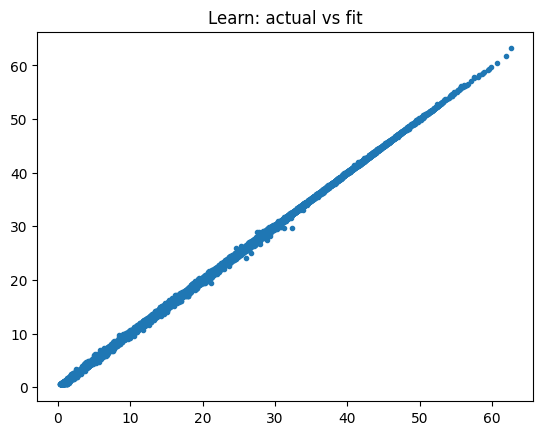

In [15]:
predict_model = model.get_layer('predict_y_model')

fit = predict_model.predict(x_to_use, batch_size=nsamples)
learn_rel_l2 = np.linalg.norm(fit[:, 0] - inputY) / np.linalg.norm(inputY)  # 	‖f−y‖₂ / ‖y‖₂
learn_rel_mae = np.linalg.norm(fit[:, 0] - inputY, ord=1) / np.linalg.norm(inputY) / np.sqrt(nsamples)  # mean|f−y| / rms(y); Note that we divide by L2 norm on purpose

print(f"learn_rel_l2 = {learn_rel_l2:.4f}, learn_rel_mae = {learn_rel_mae:.4f}")

# %matplotlib auto
%matplotlib inline
plt.plot(fit[:, 0], inputY, '.')
plt.title("Learn: actual vs fit")
plt.show()


#### **9.** Plot the Fit in 3D

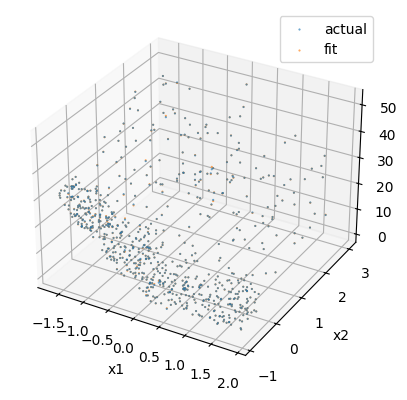

In [16]:
%matplotlib inline

plot_step = 100
ax = plt.axes(projection="3d")

ax.scatter(inputX[::plot_step, 0], inputX[::plot_step, 1], inputY[::plot_step],
           marker=".", alpha=0.75, s=1, label="actual")
ax.scatter(inputX[::plot_step, 0], inputX[::plot_step, 1], fit[::plot_step, 0], 
           marker=".", alpha=0.75, s=1, label="fit")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="best")
plt.show()


#### **10.** Calibrate the Scale on the Dense Model

In [17]:
testX = scaler.transform(test.to_numpy()[:, :-1]) 
testY = test.to_numpy()[:,-1]

fit_pk = model.get_layer("predict_y_model").get_layer("prodkernel")
fit_w = fit_pk.get_weights()  # [scales, knots] (2 entries in the FIT model)

In [ ]:
# TESTING DIFFERENT VALUES OF THE SCALE - KEPT AS A REFERENCE

# for s in (0.75, 1.00, 1.50, 2.00, 2.50, 3.00):
#     fit_pk.set_weights([np.array([[s]]), fit_w[1]])
#     test_model = gss_model_factory.generate_model_for_testing_2(
#         model, 
#         ndim=ndim, 
#         global_scale=global_scale, 
#         nodes=nodes,
#         **model_specs, 
#         l2_regularizer=1e-6, 
#         tf_dtype=tf_dtype, 
#         nsr_stretch=nsr_stretch,
#         generate_more_nodes=True,
#         max_nodes_mult=5,     # 5 × 1000 = 5000 nodes
#         sim_range=sim_range
#     )
#     f = test_model.predict(testX, batch_size=4096)
#     rel_l2 = np.linalg.norm(f[:, 0] - testY) / np.linalg.norm(testY)  # ‖f−y‖₂ / ‖y‖₂
#     rel_mae = np.linalg.norm(f[:, 0] - testY, ord=1) / np.linalg.norm(testY) / np.sqrt(test.shape[0])  # mean|f−y| / rms(y); Note that we divide by L2 norm on purpose
#     print(f"scale = {s:.2f}, test_rel_l2 = {rel_l2:.4f}, test_rel_mae = {rel_mae:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step
scale = 0.75, test_rel_l2 = 0.0048, test_rel_mae = 0.0026
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step
scale = 1.00, test_rel_l2 = 0.0042, test_rel_mae = 0.0022
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step
scale = 1.50, test_rel_l2 = 0.0039, test_rel_mae = 0.0018
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step
scale = 2.00, test_rel_l2 = 0.0032, test_rel_mae = 0.0017
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step
scale = 2.50, test_rel_l2 = 0.0041, test_rel_mae = 0.0019
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step
scale = 3.00, test_rel_l2 = 0.0068, test_rel_mae = 0.0026


We found that the best `test_model` at `scale = 2.00` with `relative L2 norm = 0.0032` from the scale sweep in the cell above (commented out, so rerun it to reproduce).

#### **11.** See the Results of the Fit for an Independently Generated Test Set (testX, testY)

In [19]:
best_scale = 2.00  # Selected based on the sweep / loop above

fit_pk.set_weights([np.array([[best_scale]]), fit_w[1]])

test_model = gss_model_factory.generate_model_for_testing_2(
    model, 
    ndim=ndim, 
    global_scale=global_scale, 
    nodes=nodes,
    **model_specs, 
    l2_regularizer=1e-6, 
    tf_dtype=tf_dtype, 
    nsr_stretch=nsr_stretch,
    generate_more_nodes=True,
    max_nodes_mult=5,     # 5 × 1000 = 5000 nodes
    sim_range=sim_range
)

test_fit = test_model.predict(testX, batch_size=4096)
test_rel_l2 = np.linalg.norm(test_fit[:, 0] - testY) / np.linalg.norm(testY)  # ‖f−y‖₂ / ‖y‖₂
test_rel_mae = np.linalg.norm(test_fit[:, 0] - testY, ord=1) / np.linalg.norm(testY) / np.sqrt(test.shape[0])  # mean|f−y| / rms(y); Note that we divide by L2 norm on purpose

print(f"scale = {best_scale:.2f}, test_rel_l2 = {test_rel_l2:.4f}, test_rel_mae = {test_rel_mae:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step
scale = 2.00, test_rel_l2 = 0.0032, test_rel_mae = 0.0017


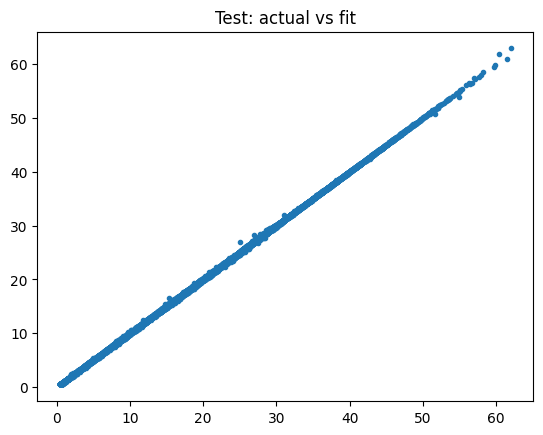

In [20]:
# %matplotlib auto
%matplotlib inline
plt.plot(test_fit[:, 0], testY, '.')
plt.title("Test: actual vs fit")
plt.show()

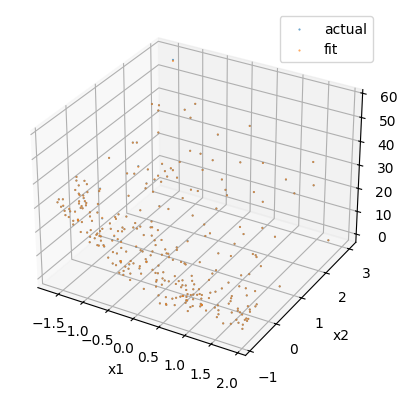

In [21]:
%matplotlib inline

plot_step = 100
ax = plt.axes(projection="3d")

ax.scatter(testX[::plot_step, 0], testX[::plot_step, 1], testY[::plot_step], 
           marker=".", alpha=0.75, s=1, label="actual")
ax.scatter(testX[::plot_step, 0], testX[::plot_step, 1], test_fit[::plot_step, 0], 
           marker=".", alpha=0.75, s=1, label="fit")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="best")
plt.show()

#### **12.** Plot Outer Weights as a Function of Nodes

In [22]:
# [0]=scales_init (phantom: auto-tracked Keras Variable), [1]=scales, [2]=knots.
# Fit model's prodkernel has only [scales, knots] -- hence [1] in cell 37, [2] here.
ws = test_model.get_layer("final").get_weights()[0][:, 0]         # Get the weights of the final layer 
test_nodes = test_model.get_layer("prodkernel").get_weights()[2]  # Get the nodes of the prodkernel layer

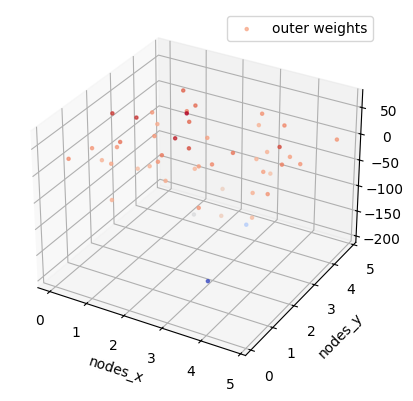

In [23]:
%matplotlib inline

plot_step = 100
ax = plt.axes(projection="3d")

ax.scatter(test_nodes[::plot_step, 0], test_nodes[::plot_step, 1], ws[::plot_step], 
           c=ws[::plot_step], cmap=cm.coolwarm, marker=".", alpha=0.75, label="outer weights")

plt.xlabel("nodes_x")
plt.ylabel("nodes_y")
plt.legend(loc="best")
plt.show()

### Fitting the Functional Tensor Train (ftt) Approximation Using the Alternating Least Squares (ALT)

#### **1.** Preparing the Learning Set

In [24]:
# Setting a Seed
input_seed = 1

# Setting the Number of Dimensions
ndim = 6

# Setting the Simulation Range
sim_range = 4

# Defining the Number of Points
nx = train.shape[0]

xs = scaler.transform(train.to_numpy()[:, :-1])
ys = train.to_numpy()[:,-1]

#### **2.** Creating (1D) Nodes, Same for Each Dimension

In [25]:
# Calculating the Number of Nodes
nnodes = 2 * int( pow(nx, 1.0/ndim) )

# Specifying the Kernel Function
kernel = 'invquad' # invquad : inverse quadratic kernel

# Setting the Multiplier for the Scale of the Kernel
scale_mult = 4.0

# Setting a Stretching Factor
stretch = 1.1

# Calculating the Global Scale
global_scale = 2 * sim_range * stretch / nnodes

# Getting the Specified Kernel Function
knl_f = ssk.global_kernel_dict(global_scale * scale_mult)[kernel]

# Generate an Array of Nodes
nodes = np.linspace(-sim_range * stretch, sim_range * stretch, nnodes, endpoint = True)

#### **3.** Specifying the Tensor Train (TT) Ranks

In [26]:
# Specifying the Rank for the Tensor Train (TT) Decommposition
# For the First and Last Dimensions
tt_flat_rank = 3

# Constructing the List of the Tensor Train Ranks
tt_ranks = [1] + [tt_flat_rank] * (ndim - 1) + [1]

#### **4.** Performing the Fitting via Alternating Least Squares (ALS)

In [27]:
# Specifying the Number of Iterations for ALS
n_iter = 5

# Recording the Starting Time to Measure the Elapsed Time
start_time = time.time()

# Calculate the Basis Function Values
bf_vals = ftt.basis_function_values(xs, nodes, knl_f)

# Setting a Seed for `np.random`
np.random.seed(input_seed)

# Initialize Tensor Train (TT) Cores for the Decomposition
init_val = None # Setting Initial Values as `None`
tt_cores = ftt.init_tt(tt_ranks, nnodes, init_val = init_val)

# Iterating through the Specified Number of Iterations for ALS
for iter in range(n_iter):
  # Iterating through Each Dimension
  for d in range(ndim):
    # Solve for Current Dimension
    # Updating Tensor Train Cores & Obtaining Fitted Values
    tt_cores, ys_fit = ftt.solve_for_dimension(d = d,
                                               tt_cores = tt_cores,
                                               bf_vals = bf_vals,
                                               ys = ys)
  # Calculate and Print the R2 for the Current Iteration
  r2 = 1 - np.linalg.norm(ys_fit - ys) / np.linalg.norm(ys) # Calculate the R2
  print(f"iter = {iter} r2 = {r2 : .4f}")

iter = 0 r2 =  0.9184
iter = 1 r2 =  0.9755
iter = 2 r2 =  0.9793
iter = 3 r2 =  0.9817
iter = 4 r2 =  0.9834
